# Benchmark of Example 2: scaling with chain length and GMRES iterations

This notebook reports the cost of the thermal XXZ chain of `examples/example2_xxz_chain_thermal.ipynb`. The measurements come from scripts in `validation/benchmarks/scripts/`, which write JSON files to `validation/results/data/`; this notebook reads those files. In this notebook you will:

- compare the dense and the sparse backend at the size of the example ($D=57$);
- follow time and memory as the chain grows from 4 to 10 sites, with and without the diagonal preconditioner;
- follow the GMRES iterations as the broadening $\eta$ decreases.

Timings were taken on one core of a laptop processor (BLAS limited to one thread), so they show scaling, not optimized performance. To measure again on your machine, set `rerun = True` in the next cell (about 30 minutes in total).

## 0. Imports and options

`run_script` launches one benchmark script with a single BLAS thread. It does nothing unless `rerun` is `True`.

In [1]:
import json
import os
import subprocess
import sys
from pathlib import Path

sys.path.insert(0, "..")

import matplotlib.pyplot as plt
import numpy as np

from models import ANALYSIS_FIGURES, DATA, results_dirs

results_dirs()
SCRIPTS = Path("scripts")
rerun = False          # True: run the scripts below


def run_script(name, *args):
    if not rerun:
        return
    env = dict(os.environ, OMP_NUM_THREADS="1", OPENBLAS_NUM_THREADS="1", MKL_NUM_THREADS="1")
    subprocess.run([sys.executable, str(SCRIPTS / name), *args], check=True, env=env)


def load(name):
    return json.loads((DATA / name).read_text())

## 1. Dense versus sparse backend at $D=57$

Script `bench_example2_dense_sparse.py` computes the three rephasing pathways of the example (thermal state, $N_{\max}=4$, $\eta=0.03$ meV) on a $5\times5$ subgrid with both backends, without preconditioner.

In [2]:
run_script("bench_example2_dense_sparse.py")
ds = load("example2_dense_sparse.json")

print(f"D = {ds['D']}, grid {ds['grid']}, eta = {ds['eta_meV']} meV")
print(f"time: dense {ds['time_dense_s']:.0f} s, sparse {ds['time_sparse_s']:.0f} s")
for name, value in ds["relative_difference"].items():
    print(f"  {name}: max|dense - sparse| / max|dense| = {value:.1e}")
assert ds["worst"] < 1e-8

D = 57, grid [5, 5], eta = 0.03 meV
time: dense 1414 s, sparse 245 s
  GSB: max|dense - sparse| / max|dense| = 5.7e-11
  SE: max|dense - sparse| / max|dense| = 5.7e-11
  ESA: max|dense - sparse| / max|dense| = 2.0e-11


The sparse backend is about six times faster and agrees with the dense one to $6\times10^{-11}$. The difference is set by the GMRES tolerance (`krylov_tolerance=1e-11`).

## 2. Scaling with the chain length

Script `bench_scaling.py` enlarges the chain from $L=4$ to $L=8$ sites at the settings of the example ($N_{\max}=4$, thermal state, $\eta=0.03$ meV), giving $D=16,31,57,99,163$. The task is a $3\times3$ subgrid. Each case runs in its own process, and the memory is the peak working set of that process. The dense backend stops at $L=6$ ($D=57$), where one Liouville matrix takes 0.17 GB. `bench_scaling.py diagonal` repeats the sparse runs with the diagonal preconditioner, up to $L=10$ ($D=386$).

backend                       L    D  time (s)  memory (MB)  mean GMRES it.
dense                         4   16      0.34          9.3
dense                         5   31     13.66        107.7
dense                         6   57    435.82       1193.6
sparse_sector                 4   16      0.19          0.6             6.8
sparse_sector                 5   31      1.12          0.6            25.9
sparse_sector                 6   57     70.68          1.8           633.3
sparse_sector                 7   99    222.72          5.2          1039.0
sparse_sector                 8  163    532.38         14.3          1251.2
sparse_sector (diagonal preconditioner)  4   16      0.08          0.6             1.0
sparse_sector (diagonal preconditioner)  5   31      0.14          0.7             1.0
sparse_sector (diagonal preconditioner)  6   57      0.27          1.0             1.0
sparse_sector (diagonal preconditioner)  7   99      0.53          3.1             1.0
sparse_sector (d

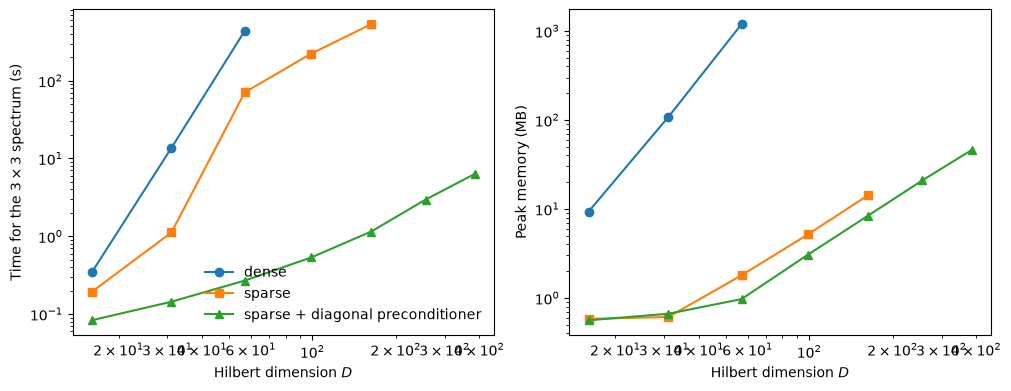

In [3]:
run_script("bench_scaling.py")
run_script("bench_scaling.py", "diagonal")
plain = load("scaling.json")
diagonal = load("scaling_diagonal.json")


def curve(rows, backend, key):
    sel = [r for r in rows if r["backend"] == backend]
    return np.array([r["D"] for r in sel]), np.array([r[key] for r in sel])


print(f"{'backend':<28}{'L':>3}{'D':>5}{'time (s)':>10}{'memory (MB)':>13}{'mean GMRES it.':>16}")
for label, rows in (("plain", plain), ("diagonal preconditioner", diagonal)):
    for r in rows:
        its = r["gmres_mean_iterations"]
        print(f"{r['backend'] + (' (' + label + ')' if label != 'plain' else ''):<28}{r['L']:>3}{r['D']:>5}"
              f"{r['spectrum_s']:>10.2f}{r['peak_MB']:>13.1f}{'' if its is None else format(its, '16.1f')}")

fig, axes = plt.subplots(1, 2, figsize=(10.0, 3.8), constrained_layout=True)
for backend, rows, style, label in (("dense", plain, "o-", "dense"),
                                    ("sparse_sector", plain, "s-", "sparse"),
                                    ("sparse_sector", diagonal, "^-", "sparse + diagonal preconditioner")):
    D, t = curve(rows, backend, "spectrum_s")
    _, m = curve(rows, backend, "peak_MB")
    axes[0].loglog(D, t, style, label=label)
    axes[1].loglog(D, m, style, label=label)
axes[0].set_xlabel("Hilbert dimension $D$"); axes[0].set_ylabel("Time for the $3\\times3$ spectrum (s)")
axes[1].set_xlabel("Hilbert dimension $D$"); axes[1].set_ylabel("Peak memory (MB)")
axes[0].legend(frameon=False)
fig.savefig(ANALYSIS_FIGURES / "example2_benchmark_scaling.pdf", bbox_inches="tight")
plt.show()

The dense time grows steeply with $D$ (a matrix inversion of size $D^2$ per point) and so does its memory ($D^4$ entries). The sparse backend stores only vectors; its time is set by the number of GMRES iterations, which here is hundreds per solve. With the preconditioner each solve takes one iteration, and the time grows gently with $D$.

In [4]:
dense_D, dense_t = curve(plain, "dense", "spectrum_s")
sparse_D, sparse_t = curve(plain, "sparse_sector", "spectrum_s")
prec_D, prec_t = curve(diagonal, "sparse_sector", "spectrum_s")
common = [d for d in prec_D if d in sparse_D]
gain = [sparse_t[list(sparse_D).index(d)] / prec_t[list(prec_D).index(d)] for d in common]
print("speed-up of the preconditioner:", ", ".join(f"D={d}: x{g:.0f}" for d, g in zip(common, gain)))
assert all(r["gmres_max_iterations"] == 1 for r in diagonal)

speed-up of the preconditioner: D=16: x2, D=31: x8, D=57: x262, D=99: x417, D=163: x463


## 3. GMRES iterations versus $\eta$

Script `bench_gmres_eta.py` fixes the model at $D=57$ and lowers $\eta$ from 0.3 to 0.003 meV; the argument `diagonal` repeats it with the preconditioner. The resolvent has a pole near the real axis at distance $\eta$, so the plain iteration count grows as $\eta$ shrinks.

 eta (meV)  plain: mean it.    max  time (s)  diagonal: mean it.  time (s)
       0.3               62     73       7.7                 1.0      0.31
       0.1              209    257      23.9                 1.0      0.28
      0.03              633    894      75.1                 1.0      0.28
      0.01             1212   2589     111.1                 1.0      0.38
     0.003             1887   4661     154.8                 1.0      0.33


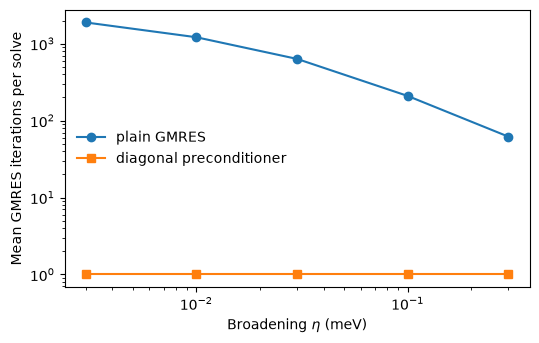

In [5]:
run_script("bench_gmres_eta.py")
run_script("bench_gmres_eta.py", "diagonal")
plain_eta = load("gmres_eta.json")
diagonal_eta = load("gmres_eta_diagonal.json")

print(f"{'eta (meV)':>10}{'plain: mean it.':>17}{'max':>7}{'time (s)':>10}{'diagonal: mean it.':>20}{'time (s)':>10}")
for a, b in zip(plain_eta, diagonal_eta):
    print(f"{a['eta_meV']:>10}{a['mean_iterations']:>17.0f}{a['max_iterations']:>7}{a['time_s']:>10.1f}"
          f"{b['mean_iterations']:>20.1f}{b['time_s']:>10.2f}")

fig, ax = plt.subplots(figsize=(6.0, 3.6))
ax.loglog([r["eta_meV"] for r in plain_eta], [r["mean_iterations"] for r in plain_eta], "o-", label="plain GMRES")
ax.loglog([r["eta_meV"] for r in diagonal_eta], [r["mean_iterations"] for r in diagonal_eta], "s-", label="diagonal preconditioner")
ax.set_xlabel(r"Broadening $\eta$ (meV)")
ax.set_ylabel("Mean GMRES iterations per solve")
ax.legend(frameon=False)
fig.savefig(ANALYSIS_FIGURES / "example2_benchmark_gmres_eta.pdf", bbox_inches="tight")
plt.show()

assert plain_eta[-1]["mean_iterations"] > 30 * plain_eta[0]["mean_iterations"]
assert all(r["max_iterations"] == 1 for r in diagonal_eta)

Without the preconditioner the count rises from about 60 to about 1900 iterations as $\eta$ decreases by a factor of 100. With it, one iteration is enough at every $\eta$. The preconditioner is exact here because the model is closed and given in its eigenbasis; with collapse channels it is only an approximation.

## Summary

- At $D=57$ the sparse backend is about six times faster than the dense one, and both agree to $\sim10^{-11}$.
- Dense time and memory grow as high powers of $D$; the sparse backend reaches $D=386$ in seconds with the diagonal preconditioner.
- GMRES iterations grow as $\eta$ decreases when unpreconditioned; the diagonal preconditioner removes this dependence for this closed model.